# 01 — Configuration 1 — Influence de la granularité temporelle (longueur de patch P)

**Question.** Quelle taille de patch représente le mieux la dynamique horaire de la production PV ?

**Hypothèses.** Un patch de 24 h correspond au cycle solaire et donne des jetons « journaliers » ; un patch de 12 h sépare matin et après-midi ; un patch de 48 h réduit le nombre de jetons (coût) mais agrège deux journées. Le pas entre patchs vaut P/2 (recouvrement 50 %).

**Paramètres fixés.** L = 168 h, traitement des canaux CA-X (attention inter-canaux + futur connu), H = 24 h.

**Protocole** (identique pour toutes les configurations — module `patchtst_pv`, section 8) :
1. entraînement sur Train (2019–2021), arrêt précoce sur Val (01–09/2022), **5 graines** ;
2. précision sur **toutes les origines horaires du Test** (10/2022–05/2023) : RMSE, MAE, nRMSE = RMSE / moyenne, R², MBE ;
3. **robustesse** : écart-type sur les graines et bruit gaussien 5 % sur les exogènes (rejet si ΔRMSE > 15 %) ;
4. **stabilité** : rolling forecast de 30 jours sans ré-entraînement, dérive = RMSE(J24–30) / RMSE(J1–7) (objectif < 1,2) ;
5. **efficience** : temps d'inférence d'un échantillon (< 100 ms) et taille des poids (< 50 Mo) ;
6. **score de décision** de `projet.md` (brut et normalisé) et tests de Diebold-Mariano contre la persistance et la moyenne.

> Les entraînements sont mis en cache (`cache/<configuration>/`) : supprimer le dossier correspondant relance
> l'entraînement complet depuis ce notebook.

In [1]:
# --- Environnement commun à tous les notebooks -------------------------------
import sys, warnings
from pathlib import Path
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m          # module commun de l'étude (entièrement commenté)
import figures_style as fs       # charte graphique des figures de l'article
fs.appliquer()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analyse as an, organigramme as org, json, dataclasses
from nb_config import configs_de

## 1. Organigramme de la configuration

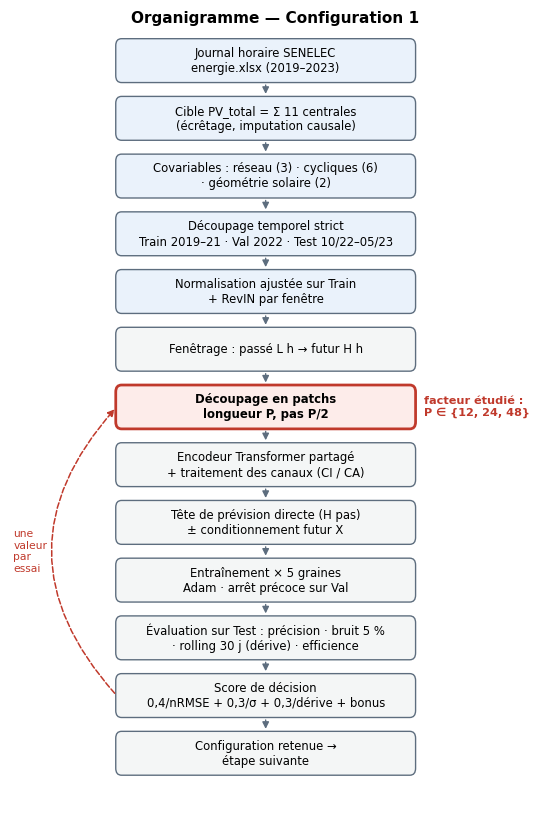

In [2]:
org.tracer(1, "Organigramme — Configuration 1", "org_config1")

## 2. Configurations évaluées

In [3]:
jeu = m.construire_jeu()
configs = configs_de(1)
pd.DataFrame([dict(nom=c.nom(), P=c.P, L=c.L, H=c.H, canaux=c.mode_canaux, futur_connu=c.futur_connu,
                   porte_physique=c.porte_physique, n_patchs=c.n_patchs) for c in configs])

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\Mes_Documents_de_these\\DOCUMENTS_RECHERCHE\\DOCUMENTS_DE_REPPORTS\\Projet_Articles_These\\Production_forecasting\\PatchTST\\PatchTST_comparaisonPV\\data\\energie.xlsx'

## 3. Entraînement et évaluation (5 graines chacune)

In [ ]:
resultats = [m.evaluer_configuration(c, jeu) for c in configs]   # relit le cache s'il existe
detail = pd.DataFrame([dict(configuration=r["nom"], **{k: g[k] for k in
         ["graine", "epoques", "duree_s", "RMSE", "MAE", "nRMSE", "R2", "degradation_bruit", "drift_7j", "drift_J30_J1"]})
         for r in resultats for g in r["par_graine"]])
detail

,configuration,graine,epoques,duree_s,RMSE,MAE,nRMSE,R2,degradation_bruit,drift_7j,drift_J30_J1
0,PatchTST-CAX_P12_L168_H24,0,17,610.0148,9.1267,5.5268,0.2062,0.9733,0.0043,0.6037,0.5437
1,PatchTST-CAX_P12_L168_H24,1,25,877.0354,9.0266,5.2093,0.2039,0.9738,0.0047,0.5992,0.6601
2,PatchTST-CAX_P12_L168_H24,2,23,791.8121,9.0612,5.2093,0.2047,0.9736,0.0037,0.5825,0.5446
3,PatchTST-CAX_P12_L168_H24,3,25,855.0012,9.0015,5.1526,0.2034,0.9740,0.0049,0.5480,0.5791
4,PatchTST-CAX_P12_L168_H24,4,25,871.2810,8.8632,4.9452,0.2002,0.9748,0.0041,0.5864,0.5486
5,PatchTST-CAX_P24_L168_H24,0,24,391.5141,9.3091,5.8056,0.2103,0.9722,0.0065,0.6128,0.5928
6,PatchTST-CAX_P24_L168_H24,1,25,402.6207,8.9803,5.0191,0.2029,0.9741,0.0055,0.5406,0.5399
7,PatchTST-CAX_P24_L168_H24,2,25,401.3566,9.0836,5.2617,0.2052,0.9735,0.0056,0.5971,0.5800
8,PatchTST-CAX_P24_L168_H24,3,16,257.5751,9.2869,5.1899,0.2098,0.9723,0.0046,0.6088,0.4956
9,PatchTST-CAX_P24_L168_H24,4,25,402.3393,8.9811,5.2757,0.2029,0.9741,0.0057,0.5389,0.5125


## 4. Tableau comparatif des métriques (moyenne sur 5 graines) et références naïves

In [ ]:
tableau = m.tableau_comparatif(resultats)
_, vrai0, orig0 = an.charger_predictions(resultats[0]["nom"])
refs = an.lignes_references(jeu, orig0, vrai0, configs[0].H) if len({c.H for c in configs}) == 1 else None
colonnes = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_jour", "R2", "MBE", "degradation_bruit",
            "drift_J30_J1", "drift_7j", "inference_ms", "taille_Mo", "n_parametres", "score", "score_normalise", "rejete_bruit"]
affiche = pd.concat([tableau[colonnes], refs], ignore_index=True) if refs is not None else tableau[colonnes]
affiche.to_csv(m.DOSSIER_TABLEAUX / "tableau_config1.csv", index=False)
affiche.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_jour,R2,MBE,degradation_bruit,drift_J30_J1,drift_7j,inference_ms,taille_Mo,n_parametres,score,score_normalise,rejete_bruit
0,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625.0,5.7561,0.8000,False
1,PatchTST-CAX_P24_L168_H24,9.1282,0.1608,5.3104,0.2062,0.2192,0.9732,0.0355,0.0056,0.5441,0.5796,2.3189,0.5346,136321.0,4.5228,0.2566,False
2,PatchTST-CAX_P48_L168_H24,9.2004,0.1030,5.2621,0.2079,0.2215,0.9728,-0.0493,0.0071,0.5240,0.5528,1.6185,0.4430,112321.0,5.5791,0.3736,False
3,Persistance J-1,10.3923,0.0000,4.9667,0.2348,NaN,0.9653,0.0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Moyenne 7 jours,10.8215,0.0000,5.3064,0.2445,NaN,0.9624,-0.0260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Lecture des colonnes.* `RMSE_std` : écart-type sur les 5 graines (robustesse). `nRMSE_jour` : nRMSE restreint aux heures
diurnes. `degradation_bruit` : hausse relative du RMSE sous bruit de 5 % sur les exogènes. `drift_J30_J1` : ratio brut de
`projet.md` (sensible à la nébulosité de deux journées isolées), `drift_7j` : ratio lissé retenu pour le score.
`score` : formule brute de `projet.md` ; `score_normalise` : chaque critère ramené à [0, 1] entre les variantes comparées.

In [ ]:
dm = an.tests_dm(jeu, resultats)
dm.round(4)

,configuration,reference,skill_score,DM,p_valeur
0,PatchTST-CAX_P12_L168_H24,persistance,0.1314,-2.9661,0.0030
1,PatchTST-CAX_P12_L168_H24,moyenne 7 j,0.1659,-3.0762,0.0021
2,PatchTST-CAX_P24_L168_H24,persistance,0.1259,-2.9013,0.0037
3,PatchTST-CAX_P24_L168_H24,moyenne 7 j,0.1606,-2.9523,0.0032
4,PatchTST-CAX_P48_L168_H24,persistance,0.1153,-2.8035,0.0051
5,PatchTST-CAX_P48_L168_H24,moyenne 7 j,0.1504,-2.9899,0.0028


## 5. Chapelet des graines et stabilité sur 30 jours

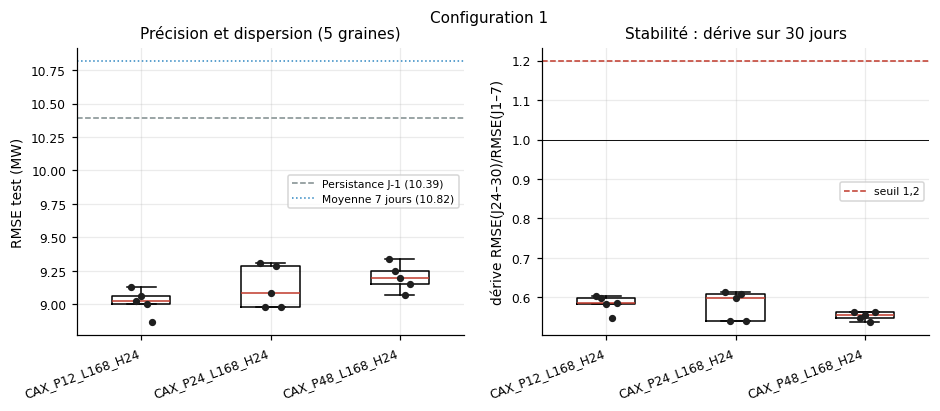

In [ ]:
an.fig_chapelet(resultats, jeu, "fig_config1_chapelet", "Configuration 1")

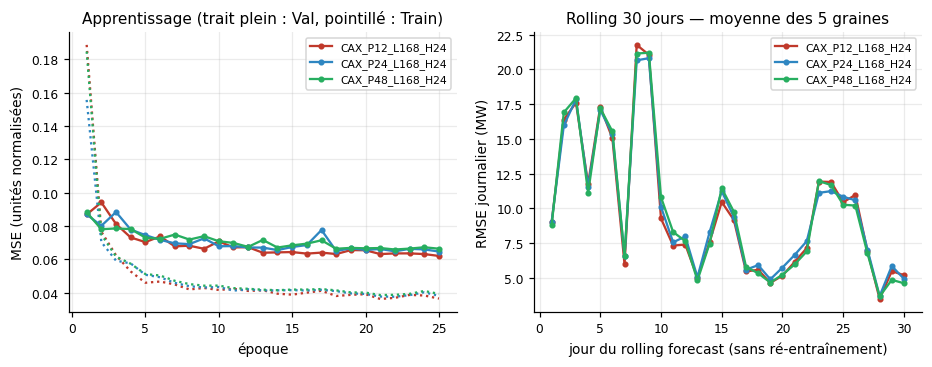

In [ ]:
an.fig_apprentissage_et_derive(resultats, "fig_config1_apprentissage_derive")

## 6. Série observée vs prédite — meilleur modèle de la configuration

Configuration retenue : PatchTST-CAX_P12_L168_H24


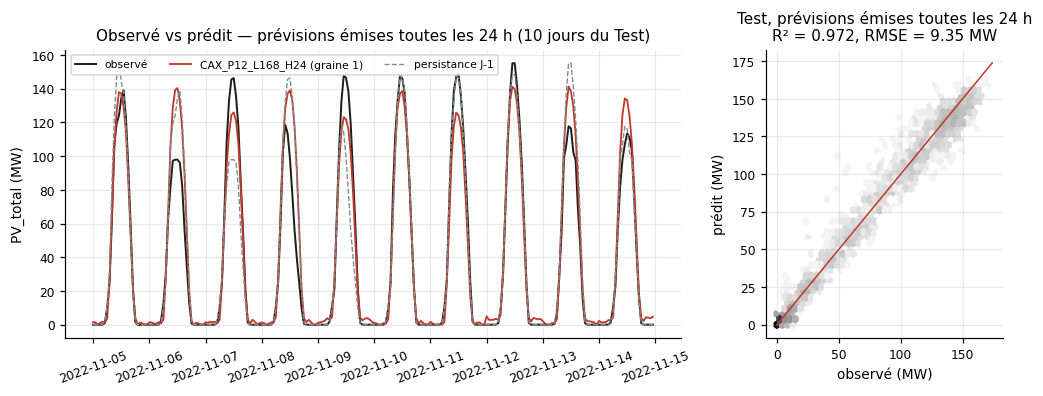

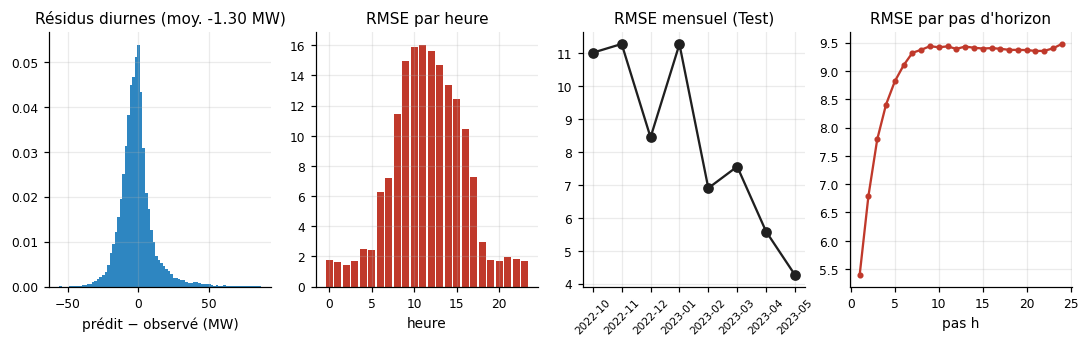

In [ ]:
retenu = an.selection_precedente("config1_patch")
print("Configuration retenue :", retenu)
res_retenu = [r for r in resultats if r["nom"] == retenu][0]
an.fig_observe_predit(res_retenu, jeu, "fig_config1_observe_predit")
an.fig_residus(res_retenu, jeu, "fig_config1_residus")

### Conclusion de la configuration 1

**Configuration retenue : `PatchTST-CAX_P12_L168_H24`** (score de décision normalisé = 0,800 ; score brut = 5,76).

- `PatchTST-CAX_P12_L168_H24` : RMSE = 9,02 ± 0,10 MW, nRMSE = 0,204, gain vs persistance = +13,2 %, dégradation sous bruit = +0,4 %, dérive 7 j = 0,58, inférence = 2,9 ms, 186 625 paramètres.
- `PatchTST-CAX_P24_L168_H24` : RMSE = 9,13 ± 0,16 MW, nRMSE = 0,206, gain vs persistance = +12,2 %, dégradation sous bruit = +0,6 %, dérive 7 j = 0,58, inférence = 2,3 ms, 136 321 paramètres.
- `PatchTST-CAX_P48_L168_H24` : RMSE = 9,20 ± 0,10 MW, nRMSE = 0,208, gain vs persistance = +11,5 %, dégradation sous bruit = +0,7 %, dérive 7 j = 0,55, inférence = 1,6 ms, 112 321 paramètres.

- Écart de RMSE entre la meilleure et la moins bonne variante : 0,18 MW (2,0 %).
- Toutes les variantes respectent le critère de robustesse (dégradation < 15 %) : oui ; toutes respectent l'objectif de dérive < 1,2 : oui ; toutes respectent l'efficience (< 100 ms, < 50 Mo) : oui.